In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

import scanpy as sc
import numpy as np
import anndata as ad

from tqdm.notebook import tqdm

In [2]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/scExpDesign-Reproducibility/project_folder/datasets/combosciplex/combosciplex.h5ad")
adata = adata[:, adata.var.highly_variable]

In [3]:
adata

View of AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.log_var = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc(x))
        z_mean = self.mean(x)
        z_log_var = self.log_var(x)
        return z_mean, z_log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, hidden_dim)
        self.reconstruct = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, z):
        z = torch.relu(self.fc(z))
        return self.reconstruct(z)

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)
    
    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        return mean + epsilon * std
    
    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, z_mean, z_log_var

    def get_latent(self, x):
        z_mean, z_log_var = self.encoder(x)
        return z_mean

    def reconstruct(self, x):
        z_mean, z_log_var = self.encoder(x)
        reconstructed_x = self.decoder(z_mean)
        return reconstructed_x

In [5]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = CustomDataset(adata.X.toarray())
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

In [56]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=10
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        recon_x, mean, log_var = model(batch)
        
        recon_loss = loss_fn(recon_x, batch)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        loss = recon_loss + 1e-6 * kl_divergence

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {kl_divergence.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1196
Epoch [1/20], Loss: 4867.6836
Epoch [2/20], Loss: 0.1152
Epoch [2/20], Loss: 3998.6133
Epoch [3/20], Loss: 0.1136
Epoch [3/20], Loss: 3851.3406
Epoch [4/20], Loss: 0.1130
Epoch [4/20], Loss: 3994.8337
Epoch [5/20], Loss: 0.1143
Epoch [5/20], Loss: 4028.7363
Epoch [6/20], Loss: 0.1140
Epoch [6/20], Loss: 3937.7017
Epoch [7/20], Loss: 0.1128
Epoch [7/20], Loss: 4014.9702
Epoch [8/20], Loss: 0.1134
Epoch [8/20], Loss: 3932.2085
Epoch [9/20], Loss: 0.1124
Epoch [9/20], Loss: 3927.2964
Epoch [10/20], Loss: 0.1113
Epoch [10/20], Loss: 3932.3408
Epoch [11/20], Loss: 0.1116
Epoch [11/20], Loss: 3975.5605
Epoch [12/20], Loss: 0.1122
Epoch [12/20], Loss: 3952.8186
Epoch [13/20], Loss: 0.1116
Epoch [13/20], Loss: 3945.8794
Epoch [14/20], Loss: 0.1123
Epoch [14/20], Loss: 3993.8008
Epoch [15/20], Loss: 0.1121
Epoch [15/20], Loss: 3910.6431
Epoch [16/20], Loss: 0.1118
Epoch [16/20], Loss: 3914.6409
Epoch [17/20], Loss: 0.1114
Epoch [17/20], Loss: 3873.4395
Epoch [18/20], 

In [57]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model.reconstruct(torch.tensor(orig).float().to(device)).cpu().numpy()

In [58]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


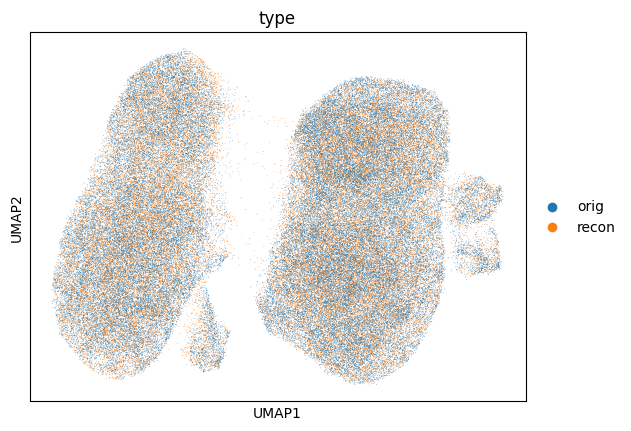

In [59]:
sc.pl.umap(combined, color="type")

In [60]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    adata.obsm["latent_10"] = model.get_latent(torch.tensor(orig).float().to(device)).cpu().numpy()

/tmp/ipykernel_4141574/323921546.py:5: ImplicitModificationWarning: Setting element `.obsm['latent_10']` of view, initializing view as actual.
  adata.obsm["latent_10"] = model.get_latent(torch.tensor(orig).float().to(device)).cpu().numpy()


In [61]:
torch.save(model.state_dict(), "ae_models/vae_10_dim.ckpt")

In [62]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=10
).to(device)
model.load_state_dict(state_dict=torch.load("ae_models/vae_10_dim.ckpt", weights_only=True))

<All keys matched successfully>

In [67]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=5
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        recon_x, mean, log_var = model(batch)
        
        recon_loss = loss_fn(recon_x, batch)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        loss = recon_loss + 1e-6 * kl_divergence

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {kl_divergence.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1187
Epoch [1/20], Loss: 4761.6738
Epoch [2/20], Loss: 0.1144
Epoch [2/20], Loss: 4184.3643
Epoch [3/20], Loss: 0.1143
Epoch [3/20], Loss: 4015.5251
Epoch [4/20], Loss: 0.1136
Epoch [4/20], Loss: 3849.2729
Epoch [5/20], Loss: 0.1123
Epoch [5/20], Loss: 3778.9331
Epoch [6/20], Loss: 0.1129
Epoch [6/20], Loss: 3738.6492
Epoch [7/20], Loss: 0.1126
Epoch [7/20], Loss: 3727.1287
Epoch [8/20], Loss: 0.1121
Epoch [8/20], Loss: 3825.8411
Epoch [9/20], Loss: 0.1128
Epoch [9/20], Loss: 3783.7646
Epoch [10/20], Loss: 0.1120
Epoch [10/20], Loss: 3696.5796
Epoch [11/20], Loss: 0.1119
Epoch [11/20], Loss: 3726.8115
Epoch [12/20], Loss: 0.1121
Epoch [12/20], Loss: 3716.5142
Epoch [13/20], Loss: 0.1113
Epoch [13/20], Loss: 3742.6475
Epoch [14/20], Loss: 0.1103
Epoch [14/20], Loss: 3751.3130
Epoch [15/20], Loss: 0.1111
Epoch [15/20], Loss: 3802.4272
Epoch [16/20], Loss: 0.1111
Epoch [16/20], Loss: 3768.3821
Epoch [17/20], Loss: 0.1119
Epoch [17/20], Loss: 3691.3792
Epoch [18/20], 

In [68]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model.reconstruct(torch.tensor(orig).float().to(device)).cpu().numpy()

In [69]:
obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")

Created
PCA
Neighbors
Finished


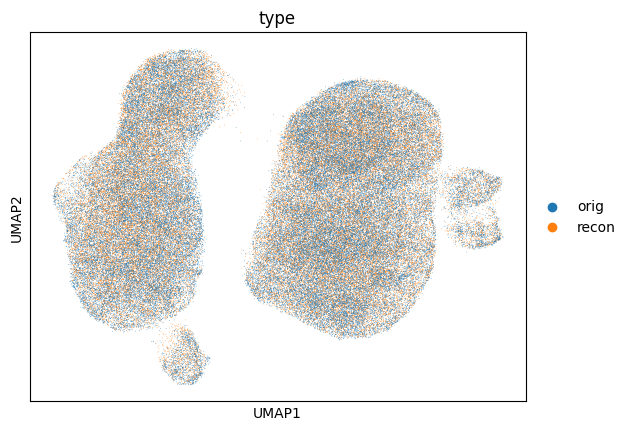

In [70]:
sc.pl.umap(combined, color="type")

In [71]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    adata.obsm["latent_5"] = model.get_latent(torch.tensor(orig).float().to(device)).cpu().numpy()

In [72]:
torch.save(model.state_dict(), "ae_models/vae_5_dim.ckpt")

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=5
).to(device)
model.load_state_dict(state_dict=torch.load("ae_models/vae_5_dim.ckpt", weights_only=True))

<All keys matched successfully>

In [76]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=3
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        recon_x, mean, log_var = model(batch)
        
        recon_loss = loss_fn(recon_x, batch)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        loss = recon_loss + 1e-6 * kl_divergence

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {kl_divergence.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1186
Epoch [1/20], Loss: 4268.4688
Epoch [2/20], Loss: 0.1157
Epoch [2/20], Loss: 3598.3208
Epoch [3/20], Loss: 0.1139
Epoch [3/20], Loss: 3408.4846
Epoch [4/20], Loss: 0.1128
Epoch [4/20], Loss: 3382.6875
Epoch [5/20], Loss: 0.1128
Epoch [5/20], Loss: 3304.0391
Epoch [6/20], Loss: 0.1141
Epoch [6/20], Loss: 3246.4634
Epoch [7/20], Loss: 0.1129
Epoch [7/20], Loss: 3197.7546
Epoch [8/20], Loss: 0.1135
Epoch [8/20], Loss: 3167.4390
Epoch [9/20], Loss: 0.1138
Epoch [9/20], Loss: 3218.7046
Epoch [10/20], Loss: 0.1124
Epoch [10/20], Loss: 3348.6196
Epoch [11/20], Loss: 0.1114
Epoch [11/20], Loss: 3276.1560
Epoch [12/20], Loss: 0.1117
Epoch [12/20], Loss: 3236.6858
Epoch [13/20], Loss: 0.1126
Epoch [13/20], Loss: 3228.5208
Epoch [14/20], Loss: 0.1109
Epoch [14/20], Loss: 3242.5869
Epoch [15/20], Loss: 0.1126
Epoch [15/20], Loss: 3245.0181
Epoch [16/20], Loss: 0.1106
Epoch [16/20], Loss: 3328.5771
Epoch [17/20], Loss: 0.1117
Epoch [17/20], Loss: 3132.7480
Epoch [18/20], 

Created
PCA
Neighbors
Finished


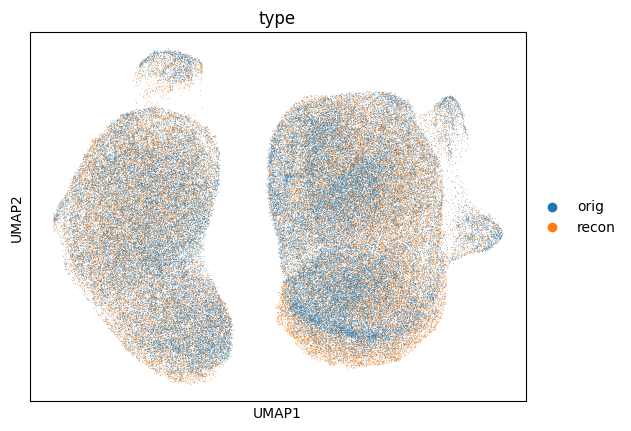

In [77]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model.reconstruct(torch.tensor(orig).float().to(device)).cpu().numpy()

obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")
sc.pl.umap(combined, color="type")

In [78]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    adata.obsm["latent_3"] = model.get_latent(torch.tensor(orig).float().to(device)).cpu().numpy()

In [79]:
torch.save(model.state_dict(), "ae_models/vae_3_dim.ckpt")

In [80]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=3
).to(device)
model.load_state_dict(state_dict=torch.load("ae_models/vae_3_dim.ckpt", weights_only=True))

<All keys matched successfully>

In [81]:
adata

AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'latent_10', 'latent_5', 'latent_3'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [82]:
adata.write_h5ad("./data/combosciplex_with_vae_latent.h5ad")

In [91]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(
    input_dim=5000,
    hidden_dim=1024,
    latent_dim=10
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        batch = batch.to(device)
        recon_x, mean, log_var = model(batch)
        
        recon_loss = loss_fn(recon_x, batch)
        kl_divergence = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        loss = recon_loss + 1e-100 * kl_divergence

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {kl_divergence.item():.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Loss: 0.1101
Epoch [1/20], Loss: 44653.7109
Epoch [2/20], Loss: 0.1055
Epoch [2/20], Loss: 47705.3672
Epoch [3/20], Loss: 0.1055
Epoch [3/20], Loss: 49513.8438
Epoch [4/20], Loss: 0.1055
Epoch [4/20], Loss: 51727.4180
Epoch [5/20], Loss: 0.1035
Epoch [5/20], Loss: 52125.5703
Epoch [6/20], Loss: 0.1043
Epoch [6/20], Loss: 51271.1992
Epoch [7/20], Loss: 0.1025
Epoch [7/20], Loss: 53214.6133
Epoch [8/20], Loss: 0.1022
Epoch [8/20], Loss: 53788.6094
Epoch [9/20], Loss: 0.1029
Epoch [9/20], Loss: 53206.1406
Epoch [10/20], Loss: 0.1026
Epoch [10/20], Loss: 54383.2773
Epoch [11/20], Loss: 0.1032
Epoch [11/20], Loss: 54267.2070
Epoch [12/20], Loss: 0.1018
Epoch [12/20], Loss: 54707.3086
Epoch [13/20], Loss: 0.1026
Epoch [13/20], Loss: 55043.5781
Epoch [14/20], Loss: 0.1024
Epoch [14/20], Loss: 54133.3125
Epoch [15/20], Loss: 0.1022
Epoch [15/20], Loss: 54916.1367
Epoch [16/20], Loss: 0.1030
Epoch [16/20], Loss: 54449.8945
Epoch [17/20], Loss: 0.1020
Epoch [17/20], Loss: 54677.820

Created
PCA
Neighbors
Finished


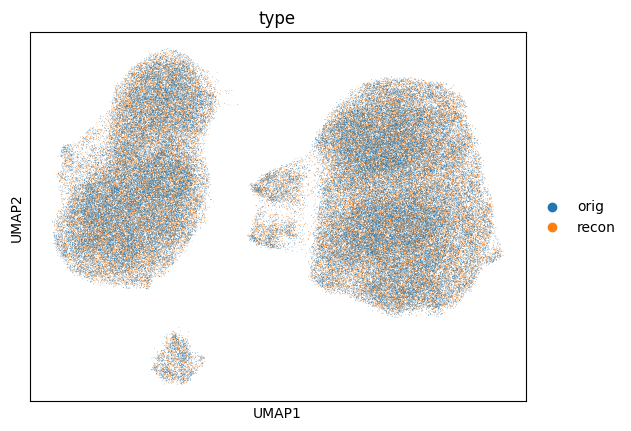

In [92]:
orig = adata.X.toarray()

model.eval()
with torch.no_grad():
    recon_scaled = model.reconstruct(torch.tensor(orig).float().to(device)).cpu().numpy()

obs = {"type": ["recon" for _ in range(recon_scaled.shape[0])] + ["orig" for _ in range(orig.shape[0])]}
combined = ad.AnnData(X=np.concatenate([recon_scaled, orig]), obs=obs)
print("Created")
sc.pp.pca(combined, n_comps=50)
print("PCA")
sc.pp.neighbors(combined)
print("Neighbors")
sc.tl.umap(combined)
print("Finished")
sc.pl.umap(combined, color="type")